# **Smart Logisctic Supply Chain Prediction**

## About Datasets

This dataset provides real-time data for smart logistics operations, capturing various aspects of supply chain management over the past year (2024). It includes information on asset tracking, inventory levels, shipment statuses, environmental conditions, traffic, and user behaviors. The dataset features multiple stakeholders within the logistics network, including asset IDs, timestamps, traffic conditions, waiting times, and reasons for delays. Additionally, the data is enriched with real-time information from IoT sensors, such as temperature, humidity, and asset utilization, to facilitate advanced logistics optimization and decision-making. The target variable, Logistics_Delay, helps in identifying delays in logistics processes, which is essential for enhancing supply chain efficiency through proactive management and optimization techniques. This dataset is designed to be used for research and machine learning applications focused on smart logistics and supply chain performance improvement.

**Source : https://www.kaggle.com/datasets/ziya07/smart-logistics-supply-chain-dataset/data**

## About Project

Dalam dunia "supply & demand" proses logistik sering terjadi dan juga cukup menantang bagi para penyedia, kita tidak bisa pungkiri proses logistik merupakan peranan penting dalam memenuhi "demand" yang terus meningkat seiring berkembangnya teknologi. Proses logistik dalam membantu ketersediaan (supply) ini juga penting dalam perputaran ekonomi, pasalnya "supply & demand" tidak akan berjalan tanpa adanya proses logistik yang baik. Walaupun terkadang dalam proses logistik banyak faktor yang dapat menghambat sehingga proses logistik dapat tertunda dan perputaran ekonomi terganggu. Namun, saaat ini kita mampu untuk mengatasi hal tersebut dengan mengoptimasi melalui model machine learning untuk melakukan prediksi apakah proses logistik tertunda atau tidak yang akan ktia lakukan dalam proyek ini.

## Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Data Load

In [3]:
df = pd.read_csv('D:\Project Data Analysis\Data & src code\Smart Logiistics Supply Chain Datasets\Data\smart_logistics_dataset.csv')
df

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,None,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,None,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,None,71.6,270,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-07-22 16:30:00,Truck_6,89.8701,73.6867,264,Delivered,26.9,70.0,Heavy,32,188,1,Weather,79.2,213,1
996,2024-04-30 04:58:58,Truck_5,-10.4792,-177.1239,479,Delivered,23.7,77.9,Detour,56,276,7,Weather,83.7,272,0
997,2024-10-27 22:09:13,Truck_2,-71.0609,75.3714,347,In Transit,21.0,63.1,Detour,35,382,5,None,74.8,275,0
998,2024-04-18 23:06:56,Truck_2,-76.7910,18.3631,276,Delivered,18.0,64.3,Heavy,10,361,5,None,88.6,242,1


**Target feature** = Logistics_Delay (1 untuk delay, 0 untuk tidak delay).

## Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   object 
 1   Asset_ID                 1000 non-null   object 
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   object 
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 non-null   float64
 8   Traffic_Status           1000 non-null   object 
 9   Waiting_Time             1000 non-null   int64  
 10  User_Transaction_Amount  1000 non-null   int64  
 11  User_Purchase_Frequency  1000 non-null   int64  
 12  Logistics_Delay_Reason   1000 non-null   object 
 13  Asset_Utilization        1000 non-null   float64
 14  Demand_Forecast          

In [5]:
df.describe()

,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-1.360093,0.837049,297.915000,23.893900,65.042200,35.062000,299.055000,5.513000,79.599100,199.284000,0.566000
std,51.997183,104.843618,113.554773,3.322178,8.753765,14.477768,117.787792,2.935379,11.631153,59.920847,0.495873
min,-89.791500,-179.820200,100.000000,18.000000,50.000000,10.000000,100.000000,1.000000,60.000000,100.000000,0.000000
25%,-46.167975,-88.448075,201.000000,21.200000,57.200000,23.000000,191.750000,3.000000,69.475000,144.000000,0.000000
50%,-4.503150,0.678300,299.000000,23.800000,65.200000,35.000000,301.500000,6.000000,79.250000,202.000000,1.000000
75%,44.502800,88.156450,399.000000,26.600000,72.400000,49.000000,405.000000,8.000000,89.425000,251.250000,1.000000
max,89.870100,179.923700,500.000000,30.000000,80.000000,60.000000,500.000000,10.000000,100.000000,300.000000,1.000000


In [6]:
# cek missing value dari setiap fitur
df.isnull().sum()

Timestamp                  0
Asset_ID                   0
Latitude                   0
Longitude                  0
Inventory_Level            0
Shipment_Status            0
Temperature                0
Humidity                   0
Traffic_Status             0
Waiting_Time               0
User_Transaction_Amount    0
User_Purchase_Frequency    0
Logistics_Delay_Reason     0
Asset_Utilization          0
Demand_Forecast            0
Logistics_Delay            0
dtype: int64

## Feature Engineering

In [7]:
# lakukan encoding pada kolom 'Traffic_Status', 'Shipment_Status', 'Logistics_Delay_Reason' dan 'Asset_ID'
le = LabelEncoder()
df['Traffic_Status_encd'] = le.fit_transform(df['Traffic_Status'])
df['Shipment_Status_encd'] = le.fit_transform(df['Shipment_Status'])
df['Logistics_Delay_Reason_encd'] = le.fit_transform(df['Logistics_Delay_Reason'])

## Exploratory Data Analysis (EDA)

### Feature Correlation

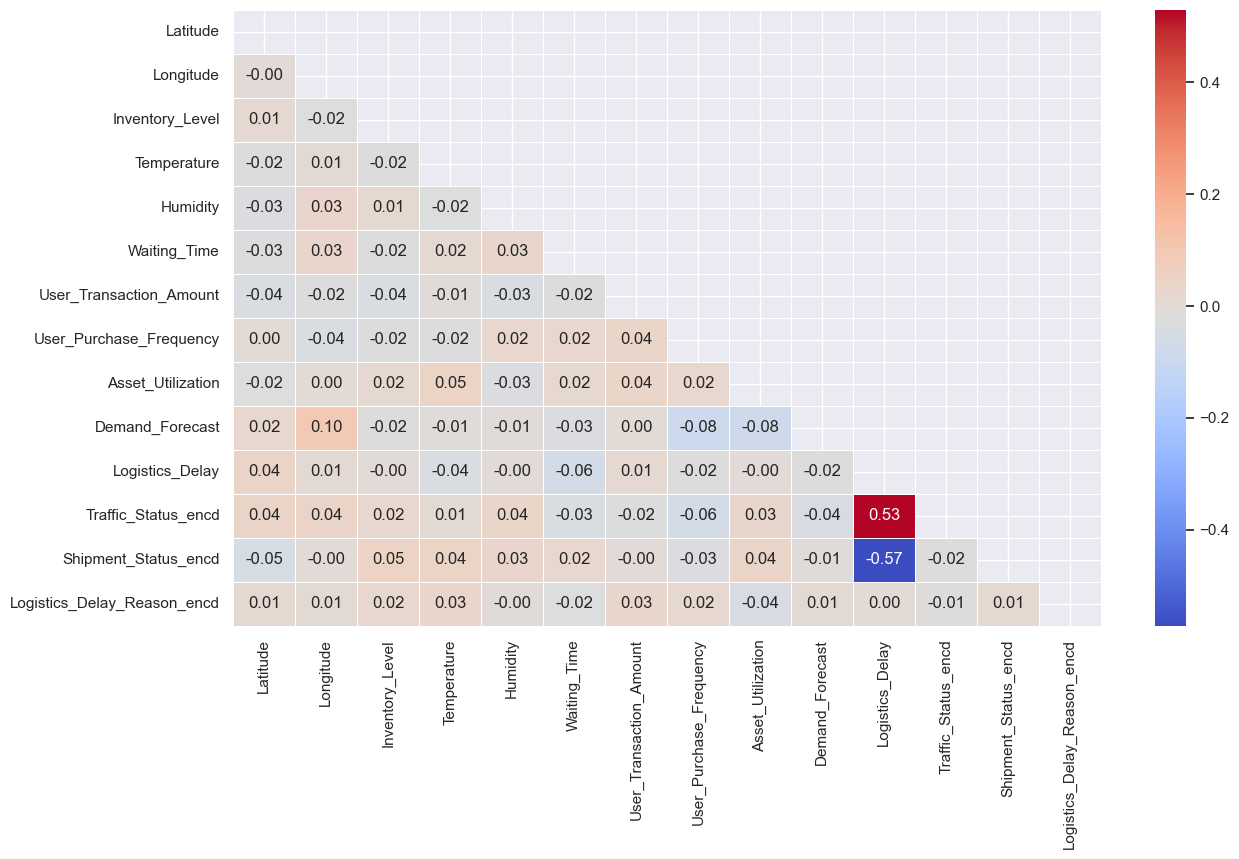

In [8]:
# Set style dengan benar
sns.set_theme(style='darkgrid')

# buat heatmap korelasi diagonal bawah saja
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(), mask=mask, cmap='coolwarm', annot=True, fmt='.2f', linewidths=.5)

plt.show()

**Traffic_Status dan Logistics_Delay (target) menjadi satu-satunya fitur yang memiliki korelasi kuat.**

### Value Counts Traffic Status

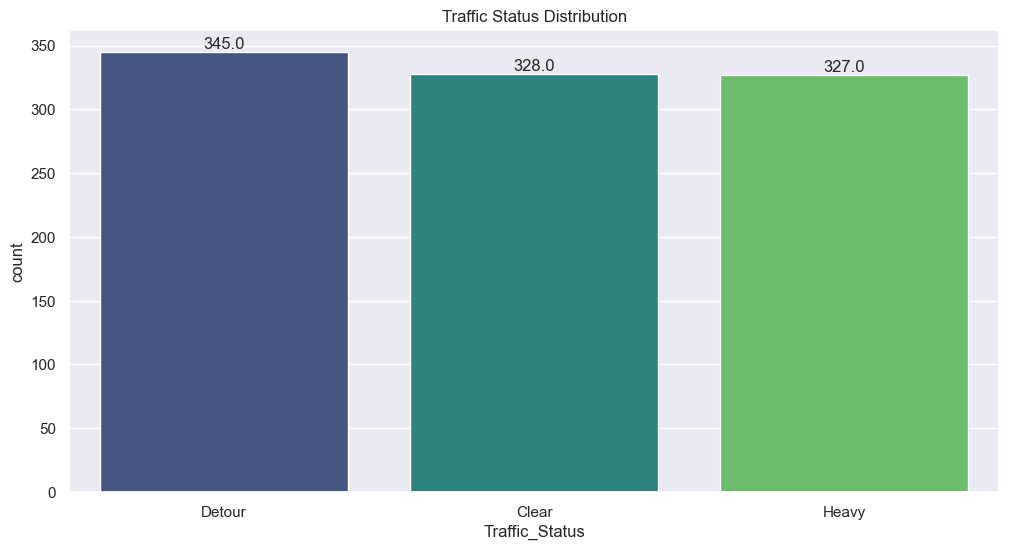

In [9]:
# buat bar chart untuk melihat banyak kategori traffic status
plt.figure(figsize=(12, 6))

# hitung jumlah setiap kategori dan urutkan dari tinggi ke rendah
order = df['Traffic_Status'].value_counts().index

# buat countplot dengan urutan yang sudah diatur
ax = sns.countplot(data=df, x='Traffic_Status', palette='viridis', order=order)

# tambahkan label angka di atas setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.title('Traffic Status Distribution')
plt.show()

### Bivariate Analysis Traffic Status with Logistics Delay Decision

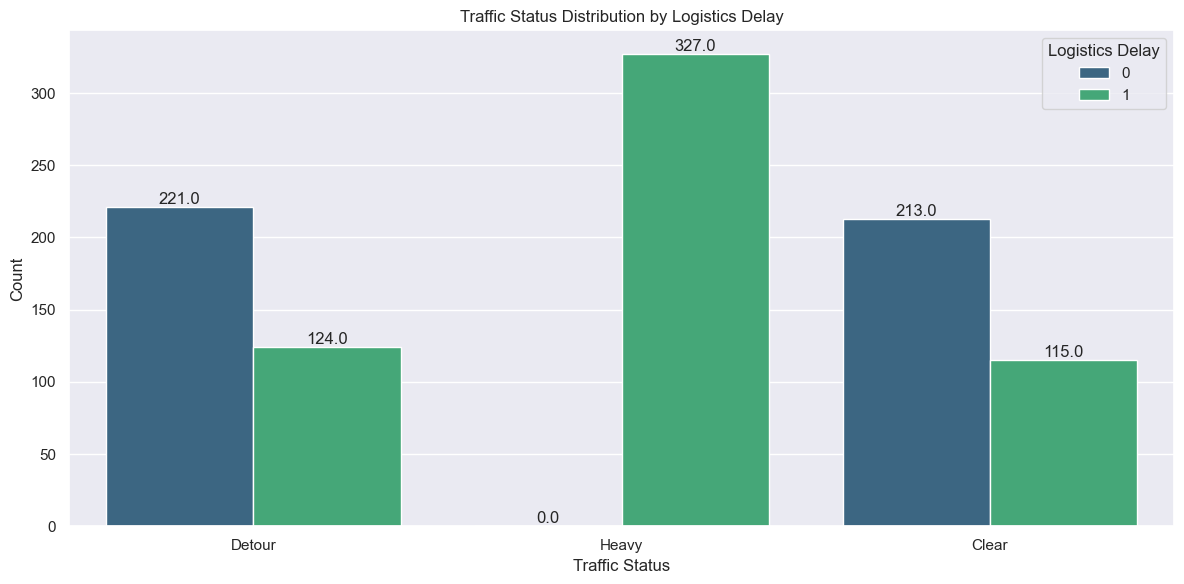

In [10]:
# Buat bar chart dari jumlah kategori Traffic_Status berdasarkan nilai Logistics_Delay
plt.figure(figsize=(12, 6))

# Buat countplot dengan hue berdasarkan Logistics_Delay
ax = sns.countplot(data=df, x='Traffic_Status', hue='Logistics_Delay', palette='viridis')

# Tambahkan label angka di atas setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

# Tambahkan judul dan label
plt.title('Traffic Status Distribution by Logistics Delay')
plt.xlabel('Traffic Status')
plt.ylabel('Count')
plt.legend(title='Logistics Delay', loc='upper right')

plt.tight_layout()  # Agar tata letak tidak terpotong
plt.show()

**Kondisi lalu lintas dan proses logistik apa pengaruhnya?**

Traffic_status merupakan data yang menunjukkan kondisi lalu lintas ketika proses logistik berlangsung. Terdapat tiga kondisi lalu lintas pada proses logistik yaitu Detour, Heavy, dan Clear. Detour berarti kondisi lalu lintas pada proses logistik mengambil jalur memutar/jalur yang berbeda, Heavy berarti kondisi lalu lintas sedang padat dan kemungkinan terdapat kemacetan, terkahir adalah clear yang berarti kondisi lalu lintas yang landai tidak ada halangan. Jika kita lihat dari analisis data di atas kondisi lalu lintas banyak berada pada status Detour,lalu dilanjutkan dengan Heavy dan Celar. Dari ketiga kondisi tersebut kondisi Heavy memiliki rasio yang hampir seluruhnya terkena delay, berbeda dengan kondisi lainnya Detour dan Clear masih banyak yang tidak delay dalam prosesnya. Hal ini cukup dapat dimaklumi adanya kondisi lalu lintas yang padat pasti mempengaruhi bagaimana logistik bisa sampai ketujuan. 

### Value Counts Shipment Status

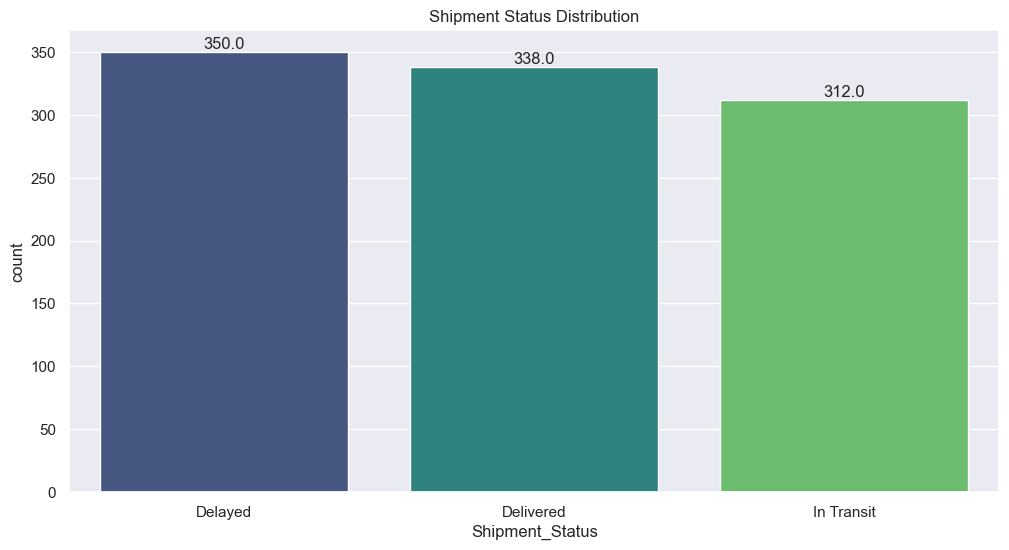

In [11]:
# buat bar chart untuk melihat banyak kategori traffic status
plt.figure(figsize=(12, 6))

# hitung jumlah setiap kategori dan urutkan dari tinggi ke rendah
order = df['Shipment_Status'].value_counts().index

# buat countplot dengan urutan yang sudah diatur
ax = sns.countplot(data=df, x='Shipment_Status', palette='viridis', order=order)

# tambahkan label angka di atas setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.title('Shipment Status Distribution')
plt.show()

### Bivariate Analysis Shipment Status with Decision Logistics Delay

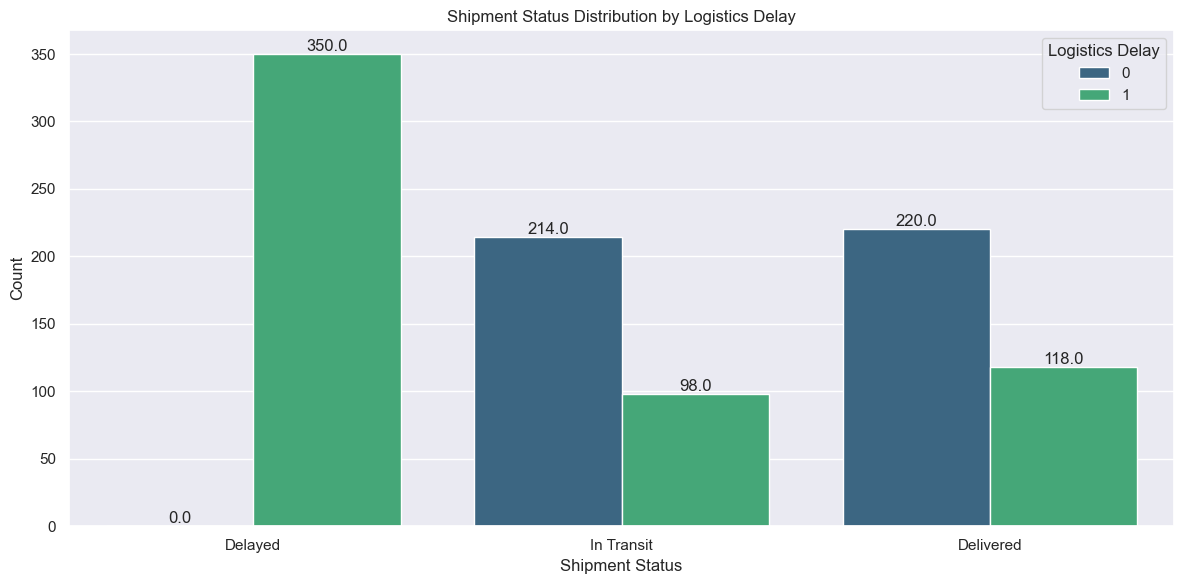

In [12]:
# Buat bar chart dari jumlah kategori Shipment_Status berdasarkan nilai Logistics_Delay
plt.figure(figsize=(12, 6))

# Buat countplot dengan hue berdasarkan Logistics_Delay
ax = sns.countplot(data=df, x='Shipment_Status', hue='Logistics_Delay', palette='viridis')

# Tambahkan label angka di atas setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

# Tambahkan judul dan label
plt.title('Shipment Status Distribution by Logistics Delay')
plt.xlabel('Shipment Status')
plt.ylabel('Count')
plt.legend(title='Logistics Delay', loc='upper right')

plt.tight_layout()  # Agar tata letak tidak terpotong
plt.show()

Shipment Status merupakan indikator yang menandakan pengantaran dalam proses logistik. Terdapat tiga indikator Delayed, In Transit, dan Deliveried. Dalam tiga indikator tersebut Delay berarti tertunda, In Transit berarti sedang dalam masa perpindahan logistik, dan Delivered berarti logistik sudah diterima. 

### Value Counts Logistics Delay Reason

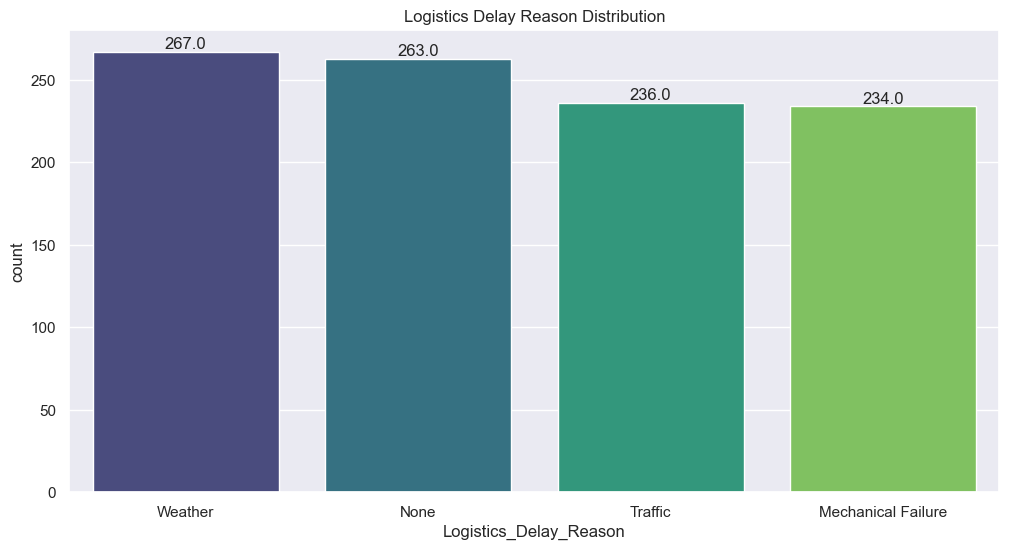

In [13]:
# buat bar chart untuk melihat banyak kategori traffic status
plt.figure(figsize=(12, 6))

# hitung jumlah setiap kategori dan urutkan dari tinggi ke rendah
order = df['Logistics_Delay_Reason'].value_counts().index

# buat countplot dengan urutan yang sudah diatur
ax = sns.countplot(data=df, x='Logistics_Delay_Reason', palette='viridis', order=order)

# tambahkan label angka di atas setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.title('Logistics Delay Reason Distribution')
plt.show()

### Bivariate Analysis Logistics Delay Reason with Decision Logistics Delay

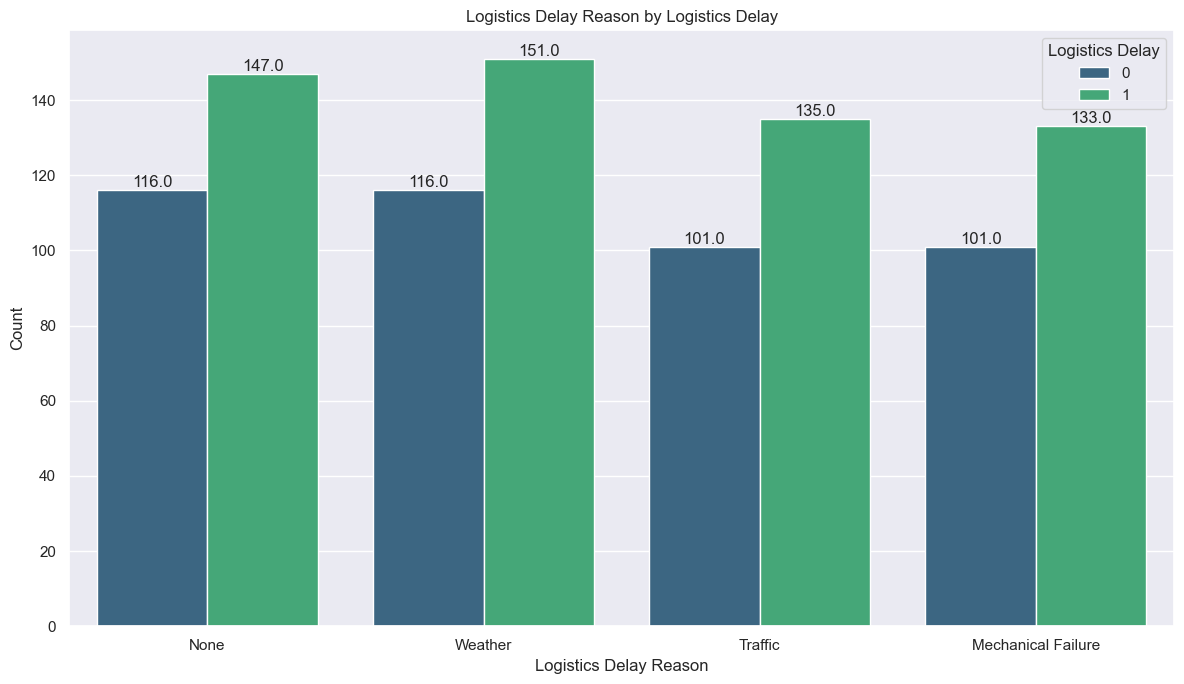

In [14]:
# Buat bar chart dari jumlah kategori Logistics_Delay_Reason berdasarkan nilai Logistics_Delay
plt.figure(figsize=(12, 7))

# Buat countplot dengan hue berdasarkan Logistics_Delay
ax = sns.countplot(data=df, x='Logistics_Delay_Reason', hue='Logistics_Delay', palette='viridis')

# Tambahkan label angka di atas setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

# Tambahkan judul dan label
plt.title('Logistics Delay Reason by Logistics Delay')
plt.xlabel('Logistics Delay Reason')
plt.ylabel('Count')
plt.legend(title='Logistics Delay', loc='upper right')

plt.tight_layout()  # Agar tata letak tidak terpotong
plt.show()

**Apa saja yang menjadi alasan delay pada proses logistik?**

Tertundanya proses logistik pasti memiliki alasan tertentu dan sering kali mempertimbangkan variabel-variabel lain. Jika dilihat dari beberapa alasan yang ada terdapat Weather (cuaca), Traffic (Lalu Lintas), Mechanical Failure (kerusakan pada sisi teknis), ataupun tanpa adanya alasan. Jika kita perhatikan hampir seluruh alasan yang ada rasio delay ditemukan lebih banyak dibandingkan yang tidak delay. Rasio delay juga banyak ditemukan pada alasan Weather (cuaca).

### Line Chart Data User Purchase Over Time

<Figure size 1200x600 with 0 Axes>

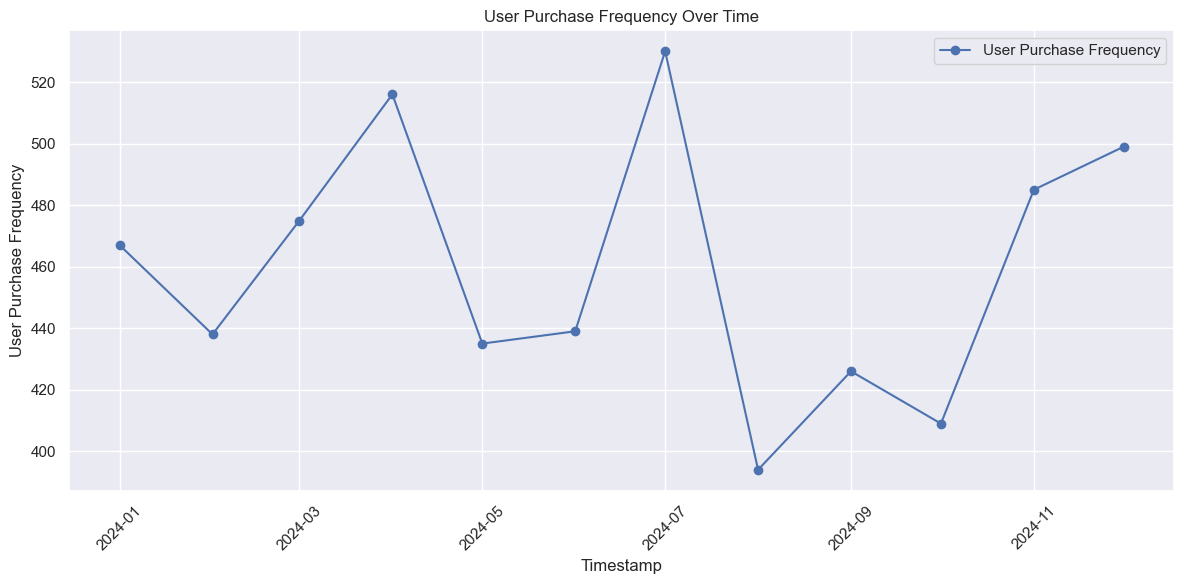

In [ ]:
# buat line chart dari timestamp untuk melihat tren User_Purchase_Frequency
plt.figure(figsize=(12, 6))
# ubah kolom 'Timestamp' menjadi tipe datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')

# buat lineplot dari timestamp berdasarkan bulan dan tahun
df['Timestamp'] = df['Timestamp'].dt.to_period('M').dt.to_timestamp()

# hitung rata-rata User_Purchase_Frequency per bulan
df_grpby = df.groupby('Timestamp').agg({'User_Purchase_Frequency': 'sum'}).reset_index()

# buat lineplot dari timestamp
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45)  # rotasi label x-axis agar lebih mudah dibaca
plt.title('User Purchase Frequency Over Time')
plt.plot(df_grpby['Timestamp'], df_grpby['User_Purchase_Frequency'], marker='o', linestyle='-')

plt.xlabel('Timestamp')
plt.ylabel('User Purchase Frequency')
plt.legend(['User Purchase Frequency'])
plt.tight_layout()  # agar tidak ada yang terpotong
plt.show()

**Tren dan pola transaksi user?**

Melihat dari sisi banyak transaksi yang dilakukan users selama tahun 2024, transaksi dari waktu ke waktu sangat fluktuatif. Transaksi tertinggi ditemukan pada **bulan ke-7** dengan lebih dari **500 transaksi**, namun menurun drastis pada **bulan ke-8** yakni kurang dari **400 transaksi**. Pola peningkatan transaksi yang dilakukan oleh user akan selalu menurun setiap 2-3 bulan dan akan mengalami peningkatan setelahnya. 

### Line Chart Average User Transacntion Amount Over Time

<Figure size 1200x600 with 0 Axes>

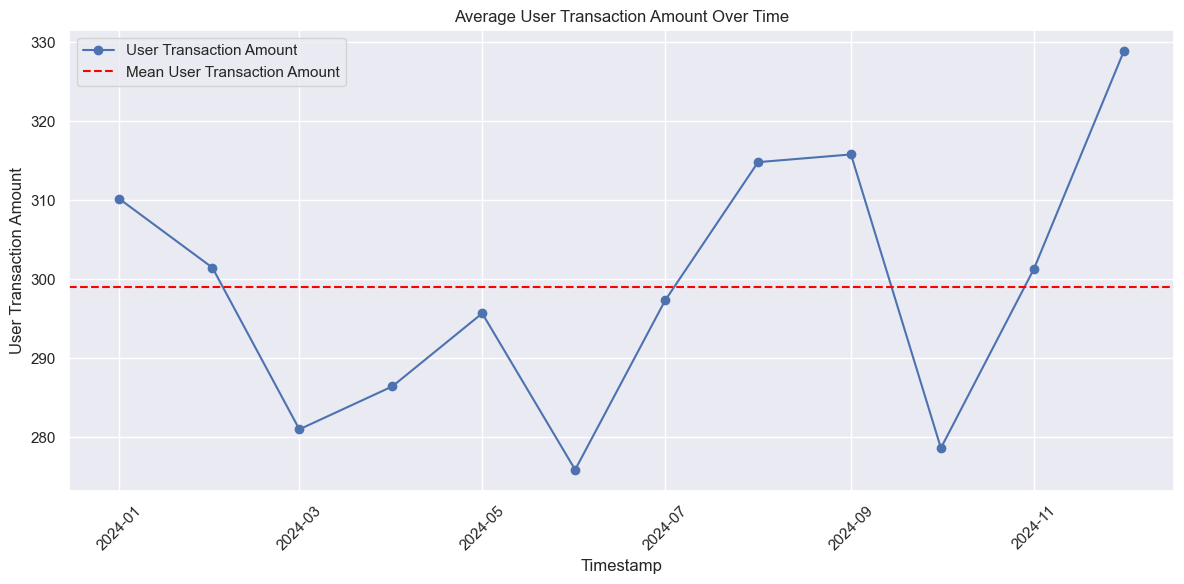

In [17]:
# buat line chart dari timestamp untuk melihat tren User_Transaction_Amount
plt.figure(figsize=(12, 6))
# ubah kolom 'Timestamp' menjadi tipe datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')

# buat lineplot dari timestamp berdasarkan bulan dan tahun
df['Timestamp'] = df['Timestamp'].dt.to_period('M').dt.to_timestamp()

# hitung rata-rata User_Purchase_Frequency per bulan
df_grpby = df.groupby('Timestamp').agg({'User_Transaction_Amount': 'mean'}).reset_index()

# buat lineplot dari timestamp
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45)  # rotasi label x-axis agar lebih mudah dibaca
plt.title('Average User Transaction Amount Over Time')
plt.plot(df_grpby['Timestamp'], df_grpby['User_Transaction_Amount'], marker='o', linestyle='-')

# tambahkan garis untuk rata-rata user transaction amount
mean_value = df['User_Transaction_Amount'].mean()
plt.axhline(mean_value, color='red', linestyle='--', label='Mean User Transaction Amount')
plt.legend(['User Transaction Amount', 'Mean User Transaction Amount'])
plt.xlabel('Timestamp')
plt.ylabel('User Transaction Amount')
plt.tight_layout()  # agar tidak ada yang terpotong
plt.show()

**Nominal transaksi user masih di bawah rata-rata?**

Dari sisi besaran nominal dari transaksi yang dilakukan oleh user dari waktu ke waktu, terdapat banyak transaksi yang masih di bawah rata-rata. Hal ini menunjukkan bahwa daya user dalam menggunakan layanan logistik belum meiliki demand yang besar.

### Line Chart Comparison Between User Transaction Amount and Demand Forecast

<Figure size 1200x600 with 0 Axes>

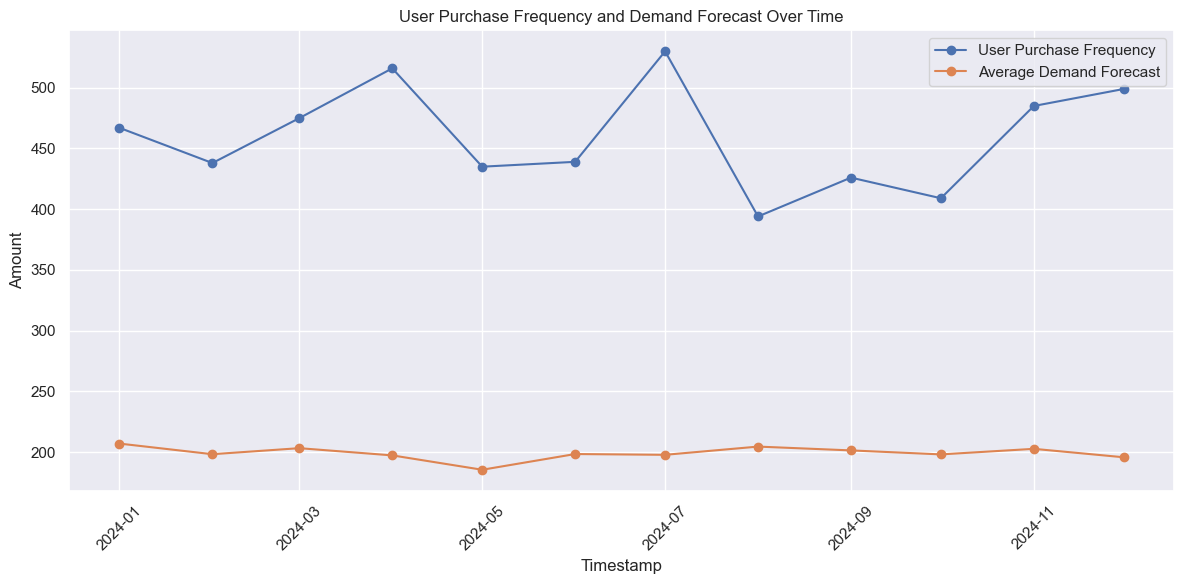

In [18]:
# buat line chart dari timestamp untuk melihat perbandingan tren dari User_Transaction_Amount dengan Demand_Forecast
plt.figure(figsize=(12, 6))
# ubah kolom 'Timestamp' menjadi tipe datetime
# df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')

# buat lineplot dari timestamp berdasarkan bulan dan tahun
# df['Timestamp'] = df['Timestamp'].dt.to_period('M').dt.to_timestamp()

# hitung jumlah total User_Transaction_Amount dan Demand_Forecast per bulan
df_grpby = df.groupby('Timestamp').agg({'User_Purchase_Frequency': 'sum', 'Demand_Forecast': 'mean'}).reset_index()

# hitung jumlah total User_Transaction_Amount dan Demand_Forecast per bulan
# df = df.groupby('Timestamp').agg({'User_Transaction_Amount': 'sum', 'Demand_Forecast': 'sum'}).reset_index()

# buat lineplot dari timestamp
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45)  # rotasi label x-axis agar lebih mudah dibaca
plt.title('User Purchase Frequency and Demand Forecast Over Time')
plt.plot(df_grpby['Timestamp'], df_grpby['User_Purchase_Frequency'], marker='o', linestyle='-', label='User Purchase Frequency')
plt.plot(df_grpby['Timestamp'], df_grpby['Demand_Forecast'], marker='o', linestyle='-', label='Demand Forecast')
plt.xlabel('Timestamp')
plt.ylabel('Amount')
plt.legend(['User Purchase Frequency', 'Average Demand Forecast'])
plt.tight_layout()  # agar tidak ada yang terpotong
plt.show()

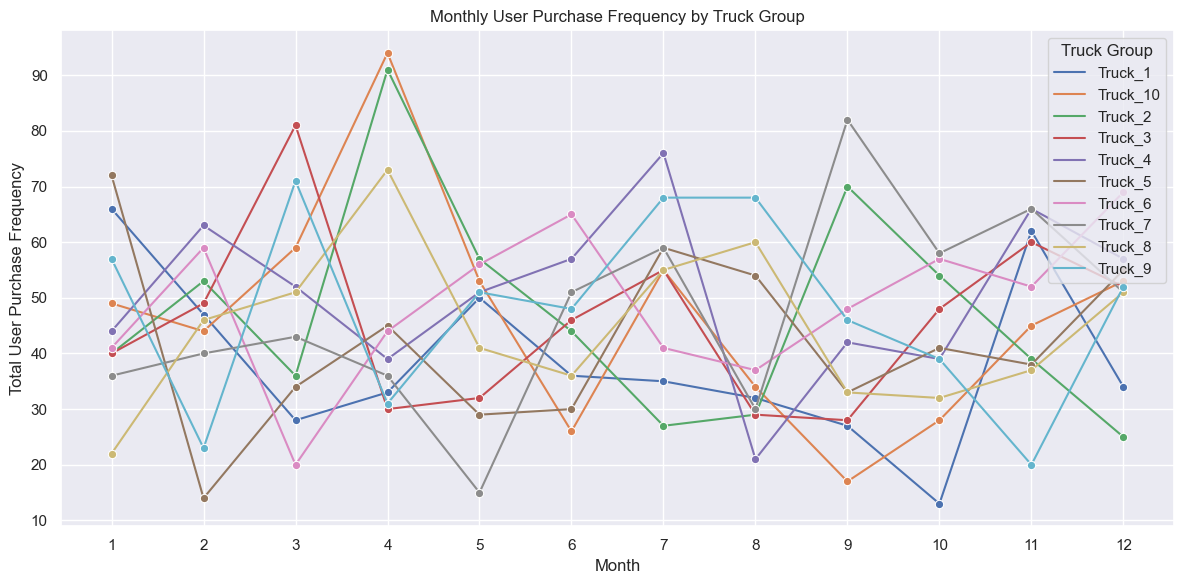

In [19]:
# Mengonversi kolom 'Timestamp' menjadi tipe datetime dan mengekstrak bulan
# df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')
df['Month'] = df['Timestamp'].dt.month

# Mengelompokkan data berdasarkan 'Truck_Group' dan 'Month', lalu menghitung total User_Purchase_Frequency
df_grpby = df.groupby(['Asset_ID', 'Month'])['User_Purchase_Frequency'].sum().reset_index()

# Membuat grafik garis untuk memvisualisasikan total User_Purchase_Frequency setiap grup truk per bulan
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grpby, x='Month', y='User_Purchase_Frequency', hue='Asset_ID', marker='o')

# Menambahkan judul dan label
plt.title('Monthly User Purchase Frequency by Truck Group')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total User Purchase Frequency', fontsize=12)
plt.legend(title='Truck Group', loc='upper right')
plt.xticks(range(1, 13))  # Memastikan bulan ditampilkan sebagai 1-12
plt.tight_layout()  # Mengatur tata letak agar tidak terpotong

# Menampilkan grafik
plt.show()

### Distribution of Waiting Time During The Logistics Processs

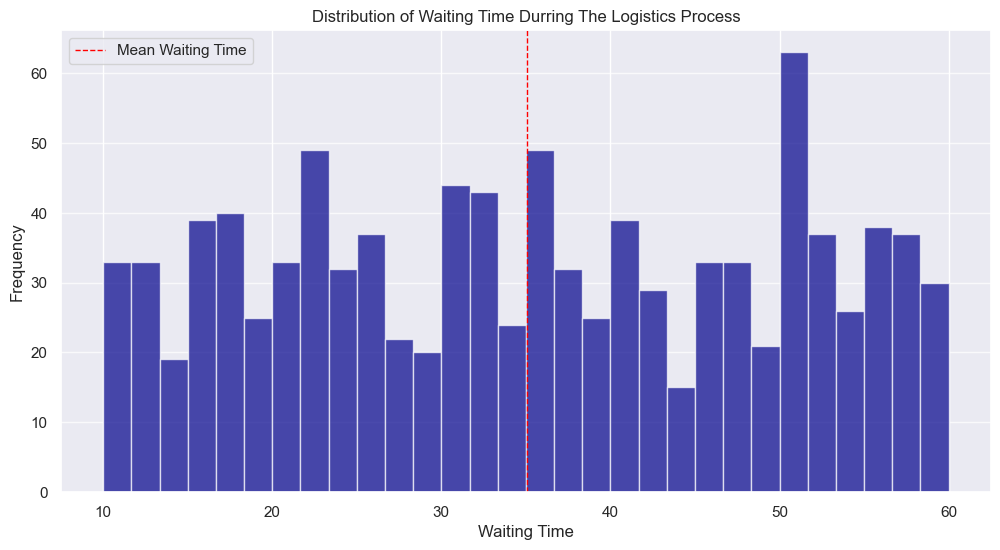

In [55]:
# buat histogram untuk melihat distribusi Waiting_Time
plt.figure(figsize=(12, 6))
plt.hist(df['Waiting_Time'], bins=30, color='DarkBlue', alpha=0.7)
plt.title('Distribution of Waiting Time Durring The Logistics Process')

# buat garis vertikal untuk mean Waiting_Time
# hitung rata-rata Waiting_Time
plt.axvline(df['Waiting_Time'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean Waiting Time')
# beri legend untuk garis mean
plt.legend()

plt.xlabel('Waiting Time')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

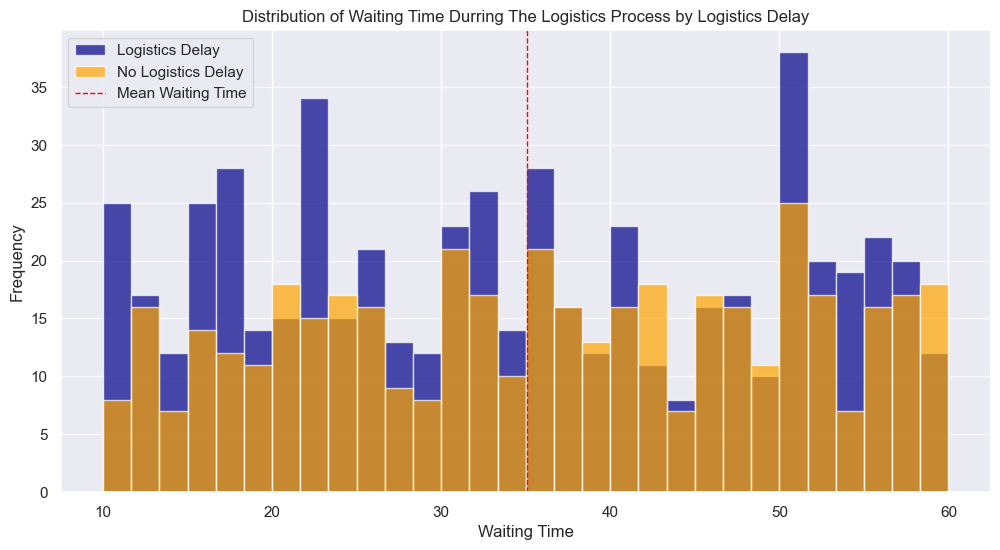

In [56]:
# buat histogram range Waiting Time berdasrarkan logistics delay
plt.figure(figsize=(12, 6))
# buat histogram untuk melihat distribusi Waiting_Time berdasarkan Logistics_Delay
plt.hist(df[df['Logistics_Delay'] == 1]['Waiting_Time'], bins=30, color='DarkBlue', alpha=0.7, label='Logistics Delay')
plt.hist(df[df['Logistics_Delay'] == 0]['Waiting_Time'], bins=30, color='orange', alpha=0.7, label='No Logistics Delay')
plt.title('Distribution of Waiting Time Durring The Logistics Process by Logistics Delay')

# buat garis vertikal untuk mean Waiting_Time
plt.axvline(df['Waiting_Time'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean Waiting Time')
# beri legend untuk garis mean
plt.legend()
plt.xlabel('Waiting Time')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Waktu tunggu mana yang lebih lama delay dan tidak delay?**

Hampir disetiap batas bawah dan atas waktu tunggu proses logistik, selalu terdapat logistik yang mendapatkan logistik delay dan tidak delay, walaupun hampir disetiap waktu frekuensi yang terkena delay lebih banyak dibandingkan yang tidak terkena delay. Ini berarti waktu tunggu yang singkat dan lama tidak mempengaruhi apakah proses logistik akan terkena delay atau tidak. Banyak faktor yang mempengaruhi hal tersebut.

### Average Waiting Time During The Logistics Process by Traffic Status

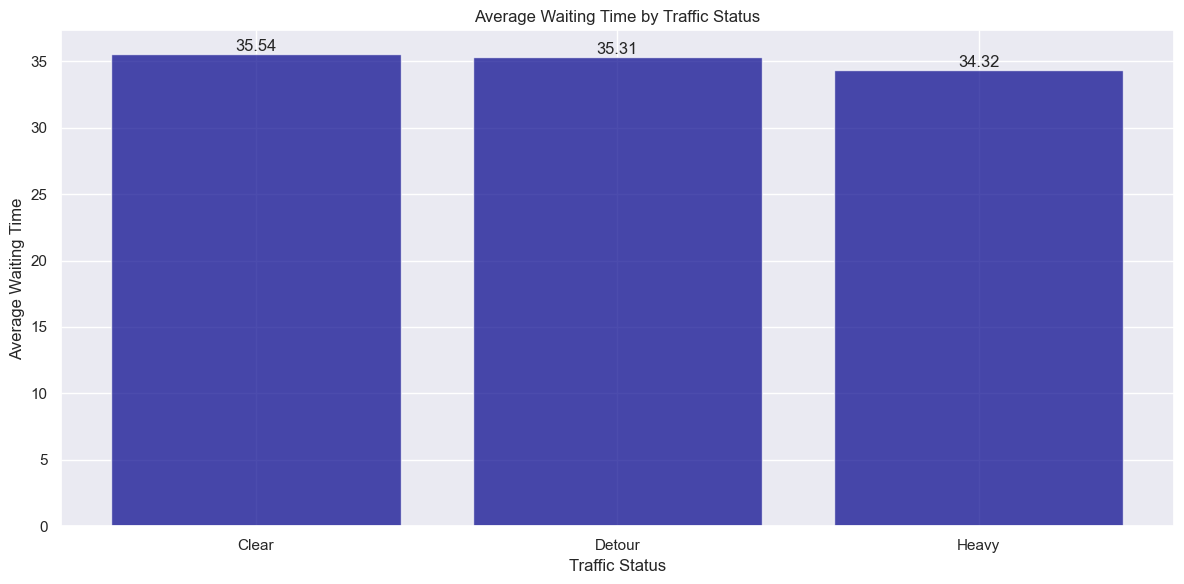

In [58]:
# hitung rata-rata waiting time berdasarkan traffic status dan tampilkan dalam bentuk bar chart
plt.figure(figsize=(12, 6))
# hitung rata-rata waiting time berdasarkan traffic status
df_grpby = df.groupby('Traffic_Status')['Waiting_Time'].mean().reset_index()
# buat bar chart dari rata-rata waiting time berdasarkan traffic status 
plt.bar(df_grpby['Traffic_Status'], df_grpby['Waiting_Time'], color='DarkBlue', alpha=0.7)

# tambahkan label angka di atas setiap bar
for i in range(len(df_grpby)):
    plt.text(i, df_grpby['Waiting_Time'][i], round(df_grpby['Waiting_Time'][i], 2), ha='center', va='bottom')


plt.title('Average Waiting Time by Traffic Status')
plt.xlabel('Traffic Status')
plt.ylabel('Average Waiting Time')
plt.tight_layout()  # agar tidak ada yang terpotong
plt.show()

**Rata-rata waktu tunggu pada Traffic_Status**

Jika kita lihat dari sisi waktu tunggu proses logistik berdasarkan Traffic_Status, ketiga indikator memiliki rata-rata lama waktu tunggu berkisar 34 hingga 35 detik.

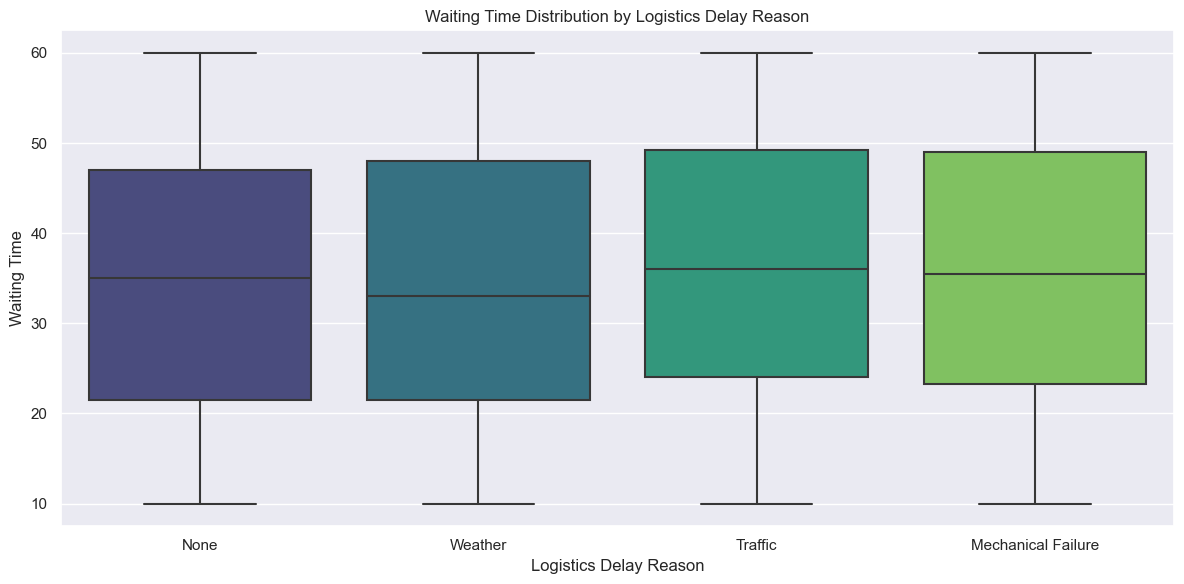

In [ ]:
# buat box plot untuk melihat distribusi nilai waiting time berdasarkan logistics delay reason
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Logistics_Delay_Reason', y='Waiting_Time', palette='viridis')
plt.title('Waiting Time Distribution by Logistics Delay Reason')
plt.xlabel('Logistics Delay Reason')
plt.ylabel('Waiting Time')
plt.tight_layout()  # Agar tata letak tidak terpotong
plt.show()

**Waktu tunggu proses logistik dilihat dari Logistics_Delay_Reason**

Dilihat Dari sisi Logistic_Delay_Reason juga menunjukkan bahwa waktu tunggu proses logistk memiliki nilai yang seimbang disetiap indikator Logistic_Delay_Reason, tidak ditemukan adanya data yang memiliki nilai yang jauh berbeda.

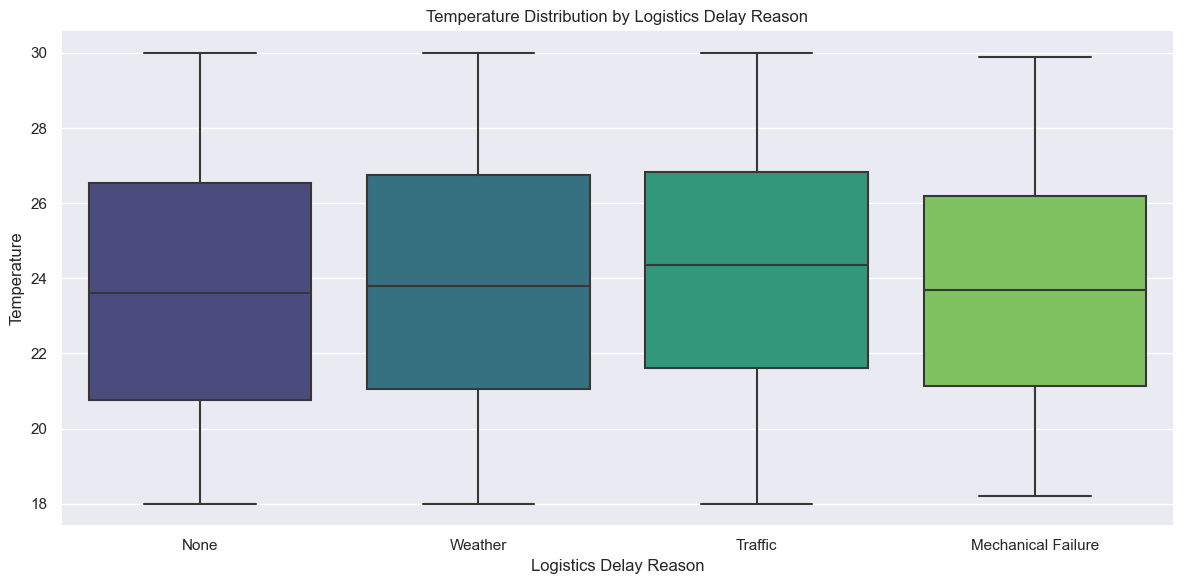

In [ ]:
# buat box plot untuk melihat distribusi nilai temperatur berdasarkan logistics delay reason
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Logistics_Delay_Reason', y='Temperature', palette='viridis')
plt.title('Temperature Distribution by Logistics Delay Reason')
plt.xlabel('Logistics Delay Reason')
plt.ylabel('Temperature')
plt.tight_layout()  # Agar tata letak tidak terpotong
plt.show()

**Apakah terdapat perbedaan jika dilihat dari alasan cuaca?**

Dari sisi alasan Weather (cuaca) dengan suhu juga tidak ditemukan adanya data yang berbeda, baik diindikator lain juga data memiliki distribusi yang seimbang dan rata-rata yang hampir sama. 

### Average Asset Utilization Based On Asset ID

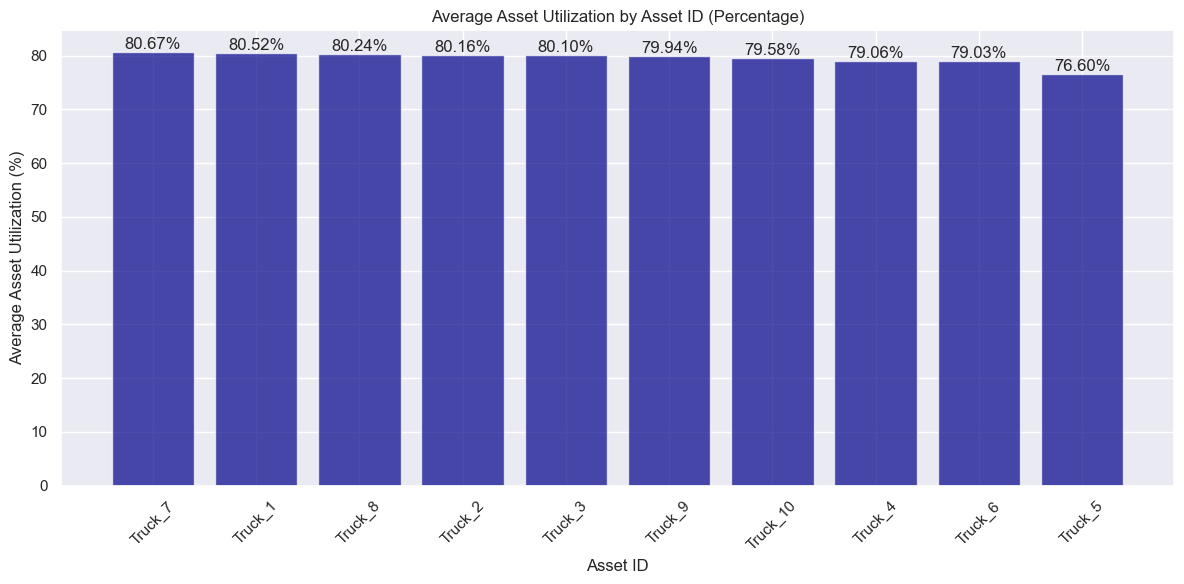

In [23]:
# Hitung rata-rata Asset_Utilization pada masing-masing Asset_ID dan tampilkan dalam bentuk bar chart
plt.figure(figsize=(12, 6))

# Hitung rata-rata Asset_Utilization berdasarkan Asset_ID
df_grpby = df.groupby('Asset_ID')['Asset_Utilization'].mean().reset_index()

# Urutkan berdasarkan rata-rata Asset_Utilization dari tinggi ke rendah
df_grpby = df_grpby.sort_values(by='Asset_Utilization', ascending=False).reset_index(drop=True)

# Buat bar chart dari rata-rata Asset_Utilization berdasarkan Asset_ID 
plt.bar(df_grpby['Asset_ID'], df_grpby['Asset_Utilization'], color='darkblue', alpha=0.7)

# Tambahkan label angka di atas setiap bar
for i in range(len(df_grpby)):
    plt.text(i, df_grpby['Asset_Utilization'].iloc[i], f"{df_grpby['Asset_Utilization'][i] :.2f}%", ha='center', va='bottom')

# Tambahkan judul dan label
plt.title('Average Asset Utilization by Asset ID (Percentage)')
plt.xlabel('Asset ID')
plt.ylabel('Average Asset Utilization (%)')
plt.xticks(rotation=45)  # Rotasi label x-axis agar lebih mudah dibaca
plt.tight_layout()  # Agar tata letak tidak terpotong

# Tampilkan grafik
plt.show()

## Data Pre-Processing

### Define Train-Test Data and Target

In [25]:
# lakukan data split train dan test dengan perbandingan 80:20
X = df.drop(columns=[
    # Data yang tidak digunakan untuk training
    'Asset_ID',
    'Timestamp',
    'Latitude',
    'Longitude',
    'Traffic_Status',
    'Shipment_Status',
    'Logistics_Delay_Reason',

    # Variabel target
    'Logistics_Delay',])

# Variabel target
y = df['Logistics_Delay']
# Lakukan split data menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# cek ukuran data train dan test
print(f"Size of data train: {X_train.shape[0]} row, {X_train.shape[1]} column")
print(f"Size of data train: {X_test.shape[0]} row, {X_test.shape[1]} column")

Size of data train: 800 row, 12 column
Size of data train: 200 row, 12 column


In [27]:
# cek proporsi data test
print(f"Proportion of target variable in test set:\n{y_test.value_counts()}\n")
# cek proporsi data train
print(f"Proportion of target variable in train set:\n{y_train.value_counts()}\n")

Proportion of target variable in test set:
1    109
0     91
Name: Logistics_Delay, dtype: int64

Proportion of target variable in train set:
1    457
0    343
Name: Logistics_Delay, dtype: int64



### Model Predicition Implementation

In [28]:
# Inisialisasi model Logistic Regression
logreg = LogisticRegression(random_state=42, max_iter=1000)

# Latih model pada data training
logreg.fit(X_train, y_train)

# Prediksi pada data test
y_pred = logreg.predict(X_test)

# Evaluasi model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
[[ 78  13]
 [  1 108]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92        91
           1       0.89      0.99      0.94       109

    accuracy                           0.93       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.94      0.93      0.93       200


Accuracy Score: 0.93


Dari skor yang didapat akurasi ditemukan 93% tanpa menggunakan hypertuning dan cross validation, hasil cukup baik dan nilai precision dan recall mampu memperikan keseimbangan dalam melakukan prediksi antara delay dan tidak delay.

In [29]:
# Definisikan parameter yang akan diuji
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],  # Regularization type
    'solver': ['liblinear', 'saga']  # Solver yang mendukung l1 dan elasticnet
}

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(estimator=logreg, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Latih GridSearchCV
grid_search.fit(X_train, y_train)

# Tampilkan hasil terbaik
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Gunakan model terbaik untuk prediksi
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# Evaluasi model terbaik
print("\nConfusion Matrix (Best Model):")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best))
print("\nAccuracy Score (Best Model):", accuracy_score(y_test, y_pred_best))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8550000000000001

Confusion Matrix (Best Model):
[[ 78  13]
 [  1 108]]

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.99      0.86      0.92        91
           1       0.89      0.99      0.94       109

    accuracy                           0.93       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.94      0.93      0.93       200


Accuracy Score (Best Model): 0.93


Dengan menggunakan Grid_search memudahkan kita akan lebih mudah memahami tuning dari model yang ingin digunakan. Dari hasil menggunakan Grid Search kita menemukan parameter dan akurasi terbaik, mulai dari regularisai (C) dengan nilai 1, dan pemanfaat 'l1' dan solver menggunkan 'liblinear' lebih cocok dalam menangani bias dan varians dengan lebih baik. 

## Evaluataion

### Confusion Matrix Heatmap

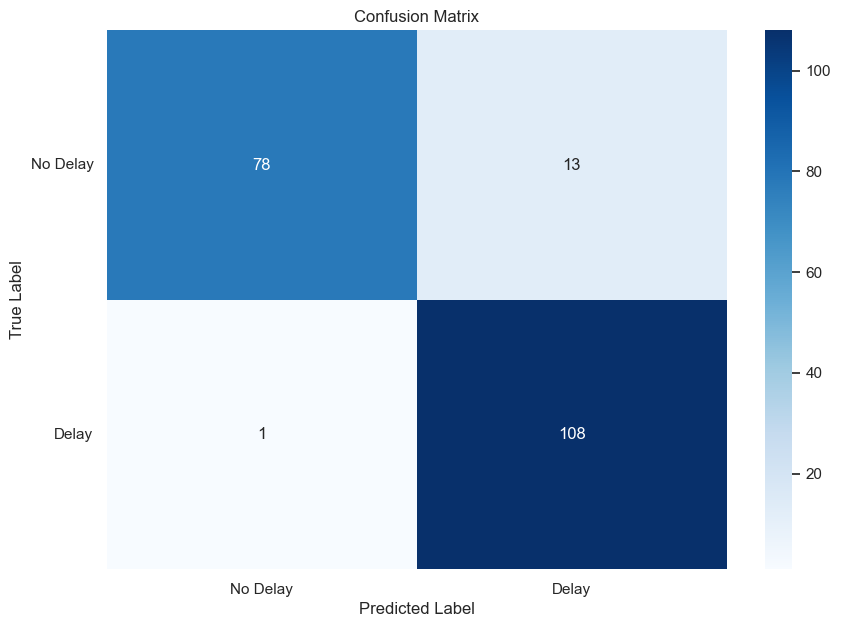

In [30]:
# buat confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(ticks=[0.5, 1.5], labels=['No Delay', 'Delay'])
plt.yticks(ticks=[0.5, 1.5], labels=['No Delay', 'Delay'], rotation=0)
plt.show()

Dalam memudahkan memahami hasil prediksi kita bisa melihat dari confusion matrix. Secara keseluruhan hasil dari model ini cukup baik dalam memprediksi true positive dan true negative begitu juga dengan false positive dan false negative. Peningkatan model masih memungkinkan untuk mendapatkan model yang lebih sensitif pada fitur tertentu. Tetapi harus mempertimbangkan kendala overfitting ataupun underfitting.

### Feature Importance Bar Chart

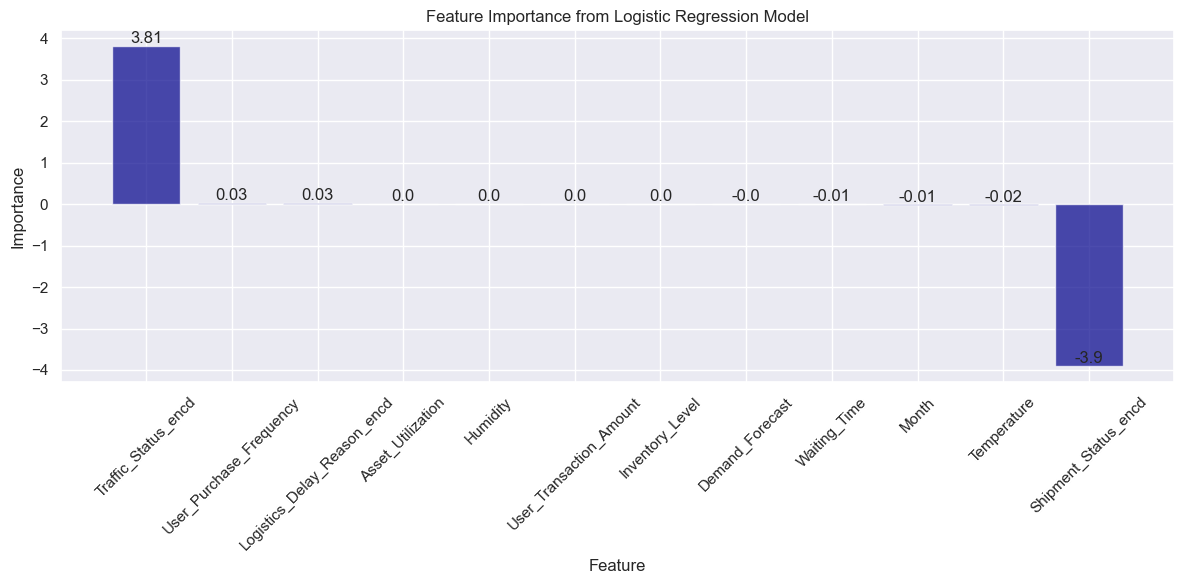

In [59]:
# buat feature importance
plt.figure(figsize=(12, 6))
# ambil koefisien dari model logistic regression
importance = logreg.coef_[0]
# ambil nama fitur dari X_train
feature_names = X_train.columns
# buat dataframe dari fitur dan koefisien
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# urutkan berdasarkan koefisien dari tinggi ke rendah
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
# buat bar chart dari feature importance
plt.bar(importance_df['Feature'], importance_df['Importance'], color='DarkBlue', alpha=0.7)
# tambahkan label angka di atas setiap bar
for i in range(len(importance_df)):
    plt.text(i, importance_df['Importance'][i], round(importance_df['Importance'][i], 2), ha='center', va='bottom')
plt.title('Feature Importance from Logistic Regression Model')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)  # rotasi label x-axis agar lebih mudah dibaca
plt.tight_layout()  # agar tidak ada yang terpotong
plt.show()

Untuk meningkatkan sensitifias dari fitur tertentu bisa kita ketahui dari feature importance. Berdasarkan model ini feature importance (fitur yang paling mempengaruhi) ada pada fitur **Traffic_Status**. Jika kita ingin melakukan prediksi dengan acuan fitur yang berbeda kita bisa melakukan pengklasifikasian yang berbeda dengan fitur tertentu untuk dijadikan sebagai variabel target.

## Conclusion

Jadi dari hasil yang telah dilakukan menggunakan model logistic regression dengan parameter regularisai (C) dengan nilai 1, dan pemanfaat 'l1' dan solver menggunkan 'liblinear' lebih cocok dalam menangani bias dan varians. Model juga sudah baik dalam memprediksi Delay dan No Delay.

Sensitivitas model bisa disesuaikan jika ingin dipriotitaskan untuk meminmilisir false positive, melalui fitur yang ada contohnya seperti User_Purchase_Frequency, dan buat lebih klasifikasi yang spesifik pada status Logistics_Delay_Reason.